In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


### 스타벅스 공식 컬러 팔레트 정의

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

SB_DEEP_GREEN = '#1E3932'
SB_GREEN      = '#006241'
SB_LIGHT_GREEN = '#D4E9E2'
SB_GOLD       = '#CBA258'
SB_GREY       = '#A2AAAD'
SB_BLACK      = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic',
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
    'xtick.color': SB_BLACK,
    'ytick.color': SB_BLACK,
    'axes.spines.top': False,    
    'axes.spines.right': False, 
    'patch.edgecolor': 'none'    
})


sns.set_palette([SB_GREEN, SB_GOLD, SB_DEEP_GREEN, SB_LIGHT_GREEN, SB_GREY])

In [3]:
merge_df = pd.read_csv("../../Data/merged_df.csv")

In [4]:
print(merge_df.info())

display(merge_df.head(5))

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   person            306137 non-null  str    
 1   event             306137 non-null  str    
 2   time              306137 non-null  int64  
 3   offer_id          167184 non-null  str    
 4   amount            138953 non-null  float64
 5   bonus_reward      33182 non-null   float64
 6   time_days         306137 non-null  int64  
 7   gender            306137 non-null  str    
 8   age               272388 non-null  float64
 9   customer_id       306137 non-null  str    
 10  became_member_on  306137 non-null  str    
 11  income            272388 non-null  float64
 12  income_missing    306137 non-null  int64  
 13  age_missing       306137 non-null  int64  
 14  reward            167184 non-null  float64
 15  difficulty        167184 non-null  float64
 16  duration          167184 non-nu

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label
0,78afa995795e4d85b5d9ceeca43f5fef,received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,1,F,75.0,78afa995795e4d85b5d9ceeca43f5fef,2017-05-09,100000.0,0,0,5.0,5.0,7.0,1.0,1.0,1.0,0.0,bogo_3
1,a03223e636434f42ac4c3df47e8bac43,received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,1,Unknown,NaN,a03223e636434f42ac4c3df47e8bac43,2017-08-04,NaN,1,1,5.0,20.0,10.0,1.0,1.0,0.0,0.0,discount_1
2,e2127556f4f64592b11af22de27a7932,received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,1,M,68.0,e2127556f4f64592b11af22de27a7932,2018-04-26,70000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4
3,8ec6ce2a7e7949b1bf142def7d0e0586,received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,1,Unknown,NaN,8ec6ce2a7e7949b1bf142def7d0e0586,2017-09-25,NaN,1,1,2.0,10.0,10.0,1.0,1.0,1.0,1.0,discount_3
4,68617ca6246f4fbc85e91a2a49552598,received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,1,Unknown,NaN,68617ca6246f4fbc85e91a2a49552598,2017-10-02,NaN,1,1,10.0,10.0,5.0,1.0,1.0,1.0,1.0,bogo_2


## Viewed 기록 중복 확인 코드

In [5]:
viewed_df = merge_df[merge_df['event'] == 'viewed']
viewed_df.head(2)

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label
12650,389bc3fa690240e798340f5a15918d5c,viewed,0,f19421c1d4aa40978ebb69ca19b0e20d,NaN,NaN,1,M,65.0,389bc3fa690240e798340f5a15918d5c,2018-02-09,53000.0,0,0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,bogo_4
12651,d1ede868e29245ea91818a903fec04c6,viewed,0,5a8bc65990b245e5a138643cd4eb9837,NaN,NaN,1,O,53.0,d1ede868e29245ea91818a903fec04c6,2017-09-16,52000.0,0,0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,informational_2


사람, 오퍼 아이디, 시간 모두 보기

In [6]:
view_counts = viewed_df.groupby(['person', 'offer_label','time']).size().reset_index(name='count')
view_counts

,person,offer_label,time,count
0,0009655768c64bdeb2e877511632db8f,bogo_4,456,1
1,0009655768c64bdeb2e877511632db8f,discount_3,540,1
2,0009655768c64bdeb2e877511632db8f,informational_1,372,1
3,0009655768c64bdeb2e877511632db8f,informational_2,192,1
4,00116118485d4dfda04fdbaba9a87b5c,bogo_4,216,1
...,...,...,...,...
57720,ffff82501cea40309d5fdd7edcca4a07,discount_1,174,1
57721,ffff82501cea40309d5fdd7edcca4a07,discount_3,6,1
57722,ffff82501cea40309d5fdd7edcca4a07,discount_4,354,1
57723,ffff82501cea40309d5fdd7edcca4a07,discount_4,414,1


중복 나오지 않음

In [7]:
multiple_views = view_counts[view_counts['count'] > 1]

if len(multiple_views) > 0:
    print(f"중복 {len(multiple_views)}건")
    display(multiple_views.sort_values(by='count', ascending=False).head(10))
else:
    print("오퍼를 딱 한 번씩만 열람")

오퍼를 딱 한 번씩만 열람


In [8]:
duplicated_views = viewed_df[viewed_df.duplicated(subset=['person', 'offer_label'], keep=False)]

duplicated_views_sorted = duplicated_views.sort_values(by=['person', 'offer_label', 'time'])
display(duplicated_views_sorted[['person', 'offer_label', 'time', 'event']].head(10))

,person,offer_label,time,event
85759,00116118485d4dfda04fdbaba9a87b5c,bogo_4,216,viewed
284119,00116118485d4dfda04fdbaba9a87b5c,bogo_4,630,viewed
105494,003d66b6608740288d6cc97a6903f4f0,discount_3,300,viewed
173027,003d66b6608740288d6cc97a6903f4f0,discount_3,420,viewed
164052,004c5799adbf42868b9cff0396190900,bogo_4,408,viewed
222247,004c5799adbf42868b9cff0396190900,bogo_4,516,viewed
69778,004c5799adbf42868b9cff0396190900,discount_3,174,viewed
289648,004c5799adbf42868b9cff0396190900,discount_3,648,viewed
33678,005500a7188546ff8a767329a2f7c76a,bogo_1,60,viewed
76664,005500a7188546ff8a767329a2f7c76a,bogo_1,186,viewed


사람 & offer label로만 봤을 때 중복되는 데이터 보기 -> time은 다른 것을 볼 수 있음

**시간이 다르기 때문에 중복이 아니라고 판단**

## 1. 총 발송 수 

오퍼 수신 이벤트만 골라서

총 몇 건의 오퍼가 뿌려졌는지 계산

오퍼를 받은 사람 수도 세보자

In [21]:
# 오퍼 수신 이벤트 (informational 제외)
received_df = merge_df[merge_df['event']=='received']

target_info = ['informational_1', 'informational_2']
received_df = received_df[~received_df['offer_label'].isin(target_info)]

# 총 몇 건의 오퍼
total_received_count = len(received_df)

# 오퍼를 받은 총 고객 수
unique_receivers = received_df['person'].nunique()

print(f"스타벅스가 뿌린 총 오퍼 건수: {total_received_count:,} 건")
print(f"오퍼를 받은 총 고객 수: {unique_receivers:,} 명")

스타벅스가 뿌린 총 오퍼 건수: 61,042 건
오퍼를 받은 총 고객 수: 16,928 명


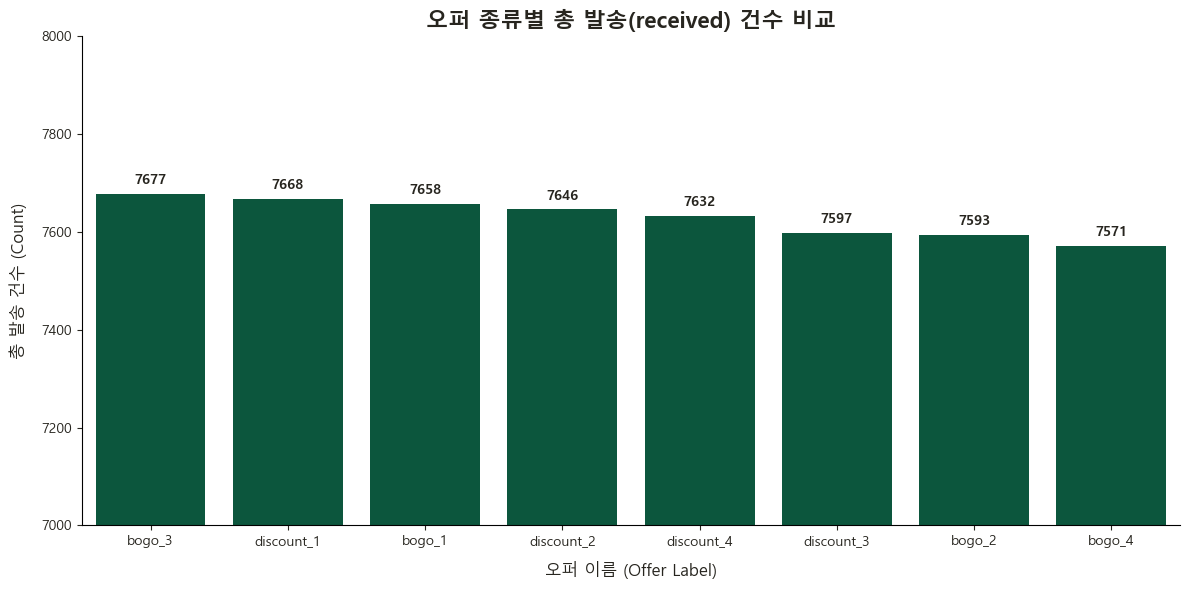

In [22]:
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=received_df, 
    x='offer_label', 
    order=received_df['offer_label'].value_counts().index
)
# y축 조절
plt.ylim(7000, 8000)

plt.title('오퍼 종류별 총 발송(received) 건수 비교', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 이름 (Offer Label)', fontsize=12, labelpad=10)
plt.ylabel('총 발송 건수 (Count)', fontsize=12, labelpad=10)

ax.bar_label(ax.containers[0], fmt='%d', padding=5, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. 총 열람 수 

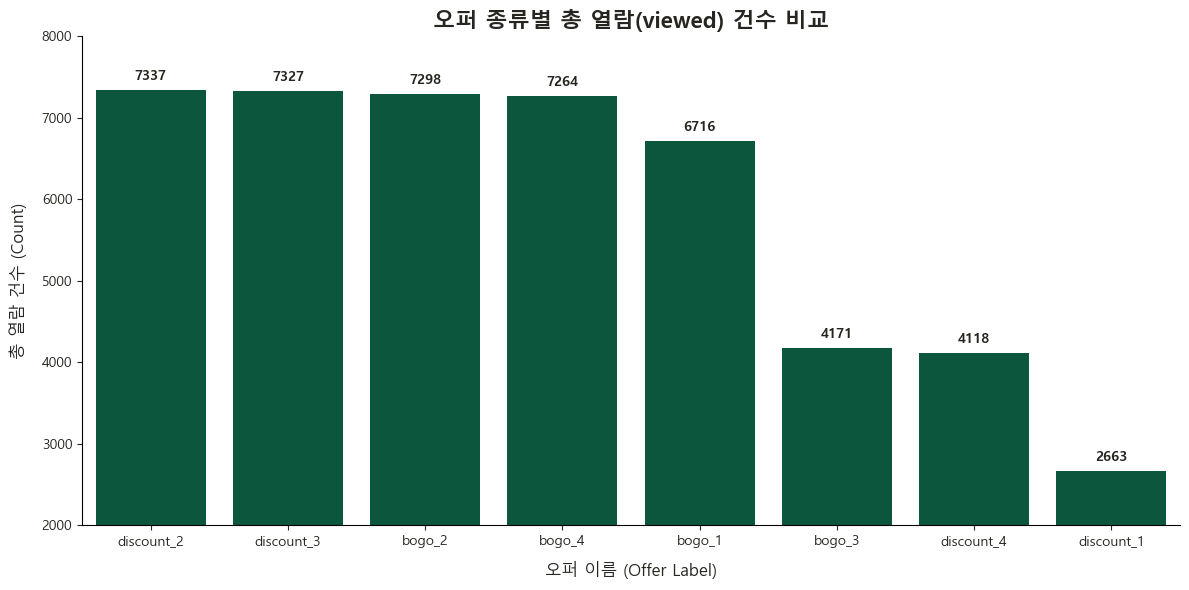

In [25]:
viewed_df = merge_df[merge_df['event'] == 'viewed']

target_info = ['informational_1', 'informational_2']
viewed_df = viewed_df[~viewed_df['offer_label'].isin(target_info)]

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=viewed_df, 
    x='offer_label', 
    order=viewed_df['offer_label'].value_counts().index
)

ax.bar_label(ax.containers[0], fmt='%d', padding=5, fontweight='bold', color=SB_BLACK)

plt.ylim(2000, 8000)

plt.title('오퍼 종류별 총 열람(viewed) 건수 비교', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 이름 (Offer Label)', fontsize=12, labelpad=10)
plt.ylabel('총 열람 건수 (Count)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

## 총 완료 수

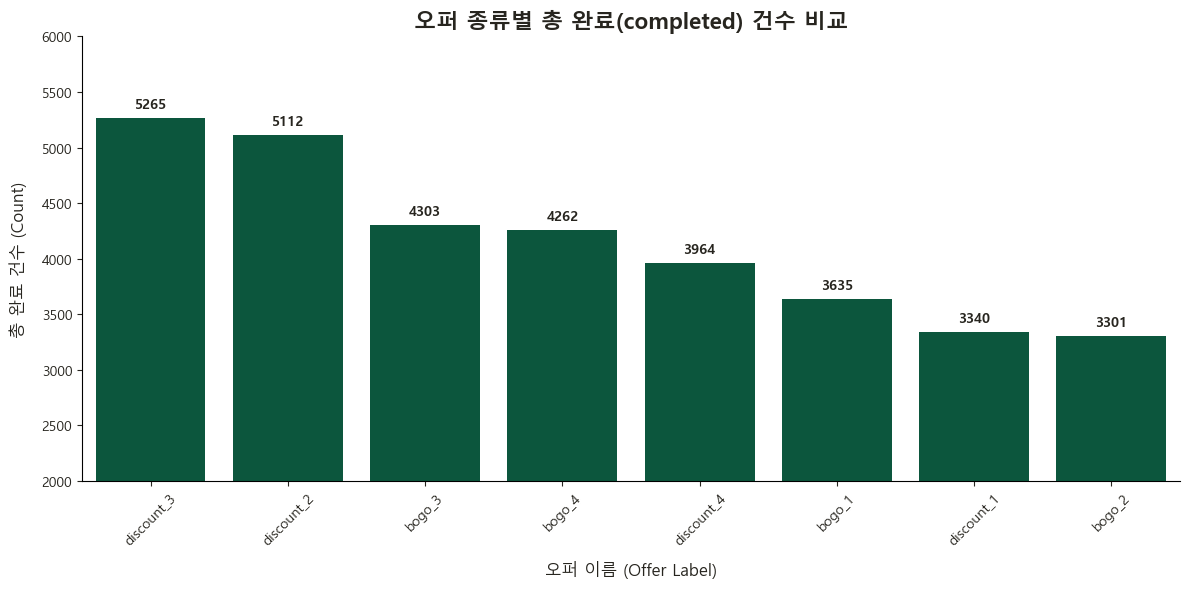

In [28]:
completed_df = merge_df[merge_df['event'] == 'completed']

target_info = ['informational_1', 'informational_2']
completed_df = completed_df[~completed_df['offer_label'].isin(target_info)]

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=completed_df, 
    x='offer_label', 
    order=completed_df['offer_label'].value_counts().index
)

ax.bar_label(ax.containers[0], fmt='%d', padding=5, fontweight='bold', color=SB_BLACK)

plt.ylim(2000, 6000)

plt.title('오퍼 종류별 총 완료(completed) 건수 비교', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 이름 (Offer Label)', fontsize=12, labelpad=10)
plt.ylabel('총 완료 건수 (Count)', fontsize=12, labelpad=10)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 전체 완료율(%)



발송과 완료의 비율 비교

완료율(%) = (완료 수 / 발송 수) * 100

In [33]:
import pandas as pd

# 1. 오퍼별로 발송(received) 건수
received_counts = received_df.groupby('offer_label').size().reset_index(name='received_count')

# 2. 오퍼별로 완료(completed) 건수
completed_counts = completed_df.groupby('offer_label').size().reset_index(name='completed_count')

# 3. 두 데이터를 'offer_label'을 기준으로 하나로 합침
funnel_df = pd.merge(received_counts, completed_counts, on='offer_label', how='left')

# 4. 완료율(%) = (완료 수 / 발송 수) * 100
funnel_df['completion_rate(%)'] = (funnel_df['completed_count'] / funnel_df['received_count']) * 100

funnel_df = funnel_df.sort_values(by='completion_rate(%)', ascending=False).reset_index(drop=True)


display(funnel_df.style.format({
    'received_count': '{:,} 건', 
    'completed_count': '{:,} 건',
    'completion_rate(%)': '{:.2f} %'
}))

,offer_label,received_count,completed_count,completion_rate(%)
0,discount_3,"7,597 건","5,265 건",69.30 %
1,discount_2,"7,646 건","5,112 건",66.86 %
2,bogo_4,"7,571 건","4,262 건",56.29 %
3,bogo_3,"7,677 건","4,303 건",56.05 %
4,discount_4,"7,632 건","3,964 건",51.94 %
5,bogo_1,"7,658 건","3,635 건",47.47 %
6,discount_1,"7,668 건","3,340 건",43.56 %
7,bogo_2,"7,593 건","3,301 건",43.47 %


In [35]:
print(received_counts.head(2))
print(completed_counts.head(2))

  offer_label  received_count
0      bogo_1            7658
1      bogo_2            7593
  offer_label  completed_count
0      bogo_1             3635
1      bogo_2             3301


#### 전체 완료율 그래프

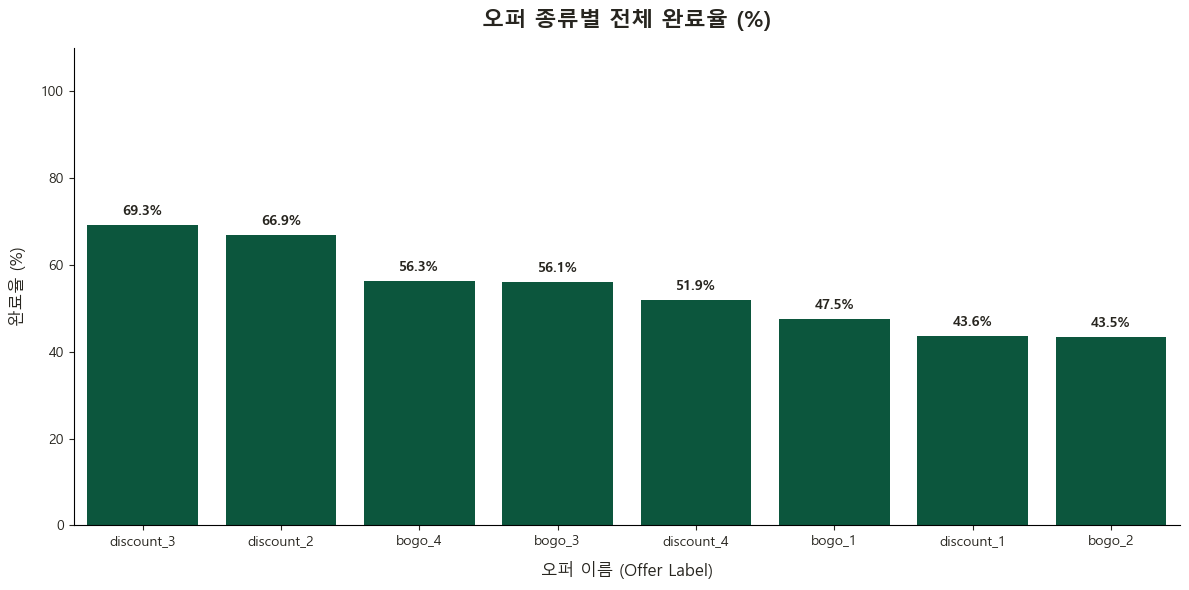

In [36]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=funnel_df, 
    x='offer_label', 
    y='completion_rate(%)'
)

ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5, fontweight='bold', color=SB_BLACK)

plt.ylim(0, 110)

plt.title('오퍼 종류별 전체 완료율 (%)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('오퍼 이름 (Offer Label)', fontsize=12, labelpad=10)
plt.ylabel('완료율 (%)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

## 총 오퍼 연계 매출 ($)

left join이후 쿠폰을 쓰고 결제한 경우에는 offer_label이 붙는다.

일반 결제는 offer_label이 nan

In [ ]:
print(completed_df.head())

                                 person  time offer_label
12658  9fa9ae8f57894cc9a3b8a9bbe0fc1b2f     0  discount_4
12672  fe97aa22dd3e48c8b143116a8403dd52     0  discount_3
12679  629fc02d56414d91bca360decdfa9288     0      bogo_3
12692  676506bad68e4161b9bbaffeb039626b     0      bogo_1
12697  8f7dd3b2afe14c078eb4f6e6fe4ba97d     0      bogo_2
                                 person  time  amount
12654  02c083884c7d45b39cc68e1314fec56c     0    0.83
12657  9fa9ae8f57894cc9a3b8a9bbe0fc1b2f     0   34.56
12659  54890f68699049c2a04d415abc25e717     0   13.23
12670  b2f1cd155b864803ad8334cdf13c4bd2     0   19.51
12671  fe97aa22dd3e48c8b143116a8403dd52     0   18.97


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 결제 데이터 준비
transactions_df = merge_df[merge_df['event'] == 'transaction'][['person', 'time', 'amount']]

# 2. left join
sales_df = pd.merge(transactions_df, completed_df, on=['person', 'time'], how='left')

# 3. 카테고리 분류기 (일반 결제 / discount / bogo)
def get_payment_category(label):
    if pd.isna(label): 
        return '일반 결제'
    elif 'discount' in str(label).lower(): 
        return 'discount'
    elif 'bogo' in str(label).lower(): 
        return 'bogo'
    else:
        return '기타'

# category 컬럼
sales_df['category'] = sales_df['offer_label'].apply(get_payment_category)

# 4. 카테고리별로 매출액(amount) 총합
revenue_summary = sales_df.groupby('category')['amount'].sum().reset_index()

# 5. 순서
order_list = ['일반 결제', 'discount', 'bogo']
revenue_summary['category'] = pd.Categorical(revenue_summary['category'], categories=order_list, ordered=True)
revenue_summary = revenue_summary.sort_values('category')


In [59]:
sales_df.head()

,person,time,amount,offer_label,category
0,02c083884c7d45b39cc68e1314fec56c,0,0.83,NaN,일반 결제
1,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,0,34.56,discount_4,discount
2,54890f68699049c2a04d415abc25e717,0,13.23,NaN,일반 결제
3,b2f1cd155b864803ad8334cdf13c4bd2,0,19.51,NaN,일반 결제
4,fe97aa22dd3e48c8b143116a8403dd52,0,18.97,discount_3,discount


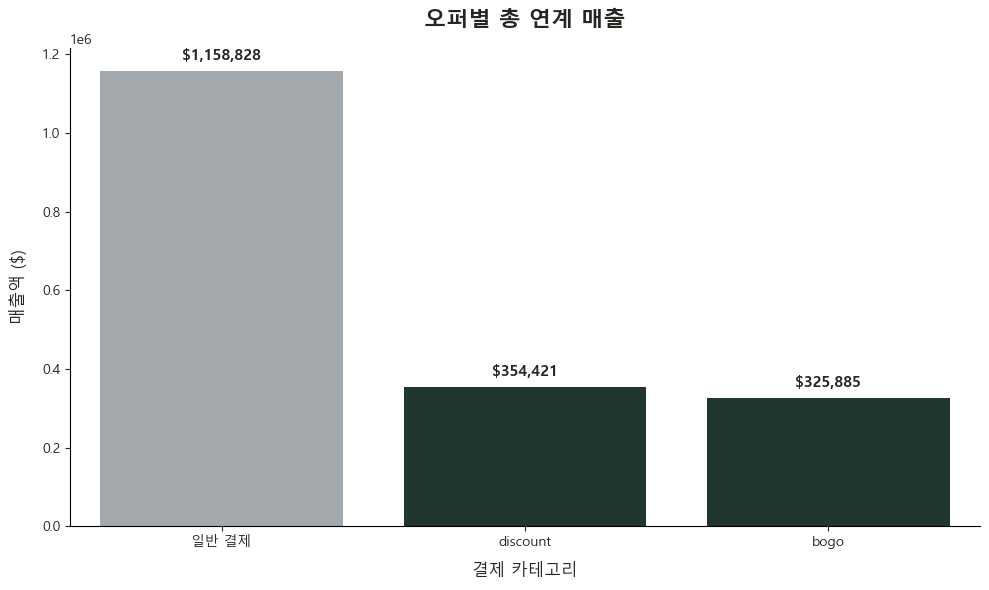

In [60]:
plt.figure(figsize=(10, 6))

color_palette = [SB_GREY, SB_DEEP_GREEN, SB_DEEP_GREEN]

ax = sns.barplot(
    data=revenue_summary, 
    x='category', 
    y='amount', 
    palette=color_palette
)

for container in ax.containers:
    labels = [f'${int(val):,}'  for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontweight='bold', color='#27251F', fontsize=11)

plt.title('오퍼별 총 연계 매출', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=10)
plt.ylabel('매출액 ($)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

### 발송 1건당 평균 매출

1건당 평균 매출 = 총매출액 / 총 발송 건수

In [63]:
# 1. 오퍼별로 총 발송 건수
sent_counts = received_df.groupby('offer_label').size().reset_index(name='sent_count')

# 2. 오퍼별 총 매출액 구하기
offer_revenue = sales_df.dropna(subset=['offer_label'])
revenue_per_offer = offer_revenue.groupby('offer_label')['amount'].sum().reset_index(name='total_revenue')

# 3. 데이터 합치기 (발송 건수 옆에 총매출액 붙이기)
roi_df = pd.merge(sent_counts, revenue_per_offer, on='offer_label', how='left')

# 빈칸은 0으로
roi_df['total_revenue'] = roi_df['total_revenue'].fillna(0)

# 4. 1건당 평균 매출 = 총매출액 / 총 발송 건수
roi_df['revenue_per_send($)'] = roi_df['total_revenue'] / roi_df['sent_count']

# 순서
roi_df = roi_df.sort_values(by='revenue_per_send($)', ascending=False).reset_index(drop=True)

오퍼별로 총 발송 건수

In [68]:
sent_counts

,offer_label,sent_count
0,bogo_1,7658
1,bogo_2,7593
2,bogo_3,7677
3,bogo_4,7571
4,discount_1,7668
5,discount_2,7646
6,discount_3,7597
7,discount_4,7632


오퍼별 총 매출

In [69]:
revenue_per_offer

,offer_label,total_revenue
0,bogo_1,87109.94
1,bogo_2,78562.14
2,bogo_3,77066.31
3,bogo_4,83146.93
4,discount_1,85985.53
5,discount_2,89848.17
6,discount_3,96900.08
7,discount_4,81687.95


1건당 평균 매출

In [65]:
roi_df

,offer_label,sent_count,total_revenue,revenue_per_send($)
0,discount_3,7597,96900.08,12.755045
1,discount_2,7646,89848.17,11.751003
2,bogo_1,7658,87109.94,11.375025
3,discount_1,7668,85985.53,11.213554
4,bogo_4,7571,83146.93,10.982292
5,discount_4,7632,81687.95,10.703348
6,bogo_2,7593,78562.14,10.346653
7,bogo_3,7677,77066.31,10.038597


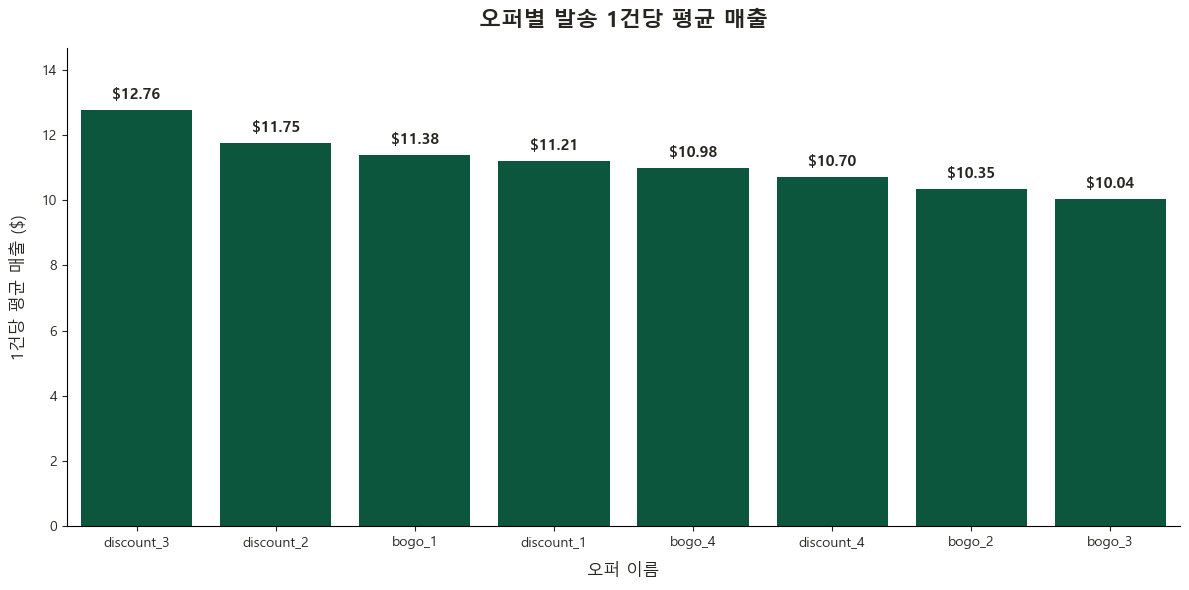


[오퍼별 효율성 상세 데이터]


,offer_label,sent_count,total_revenue,revenue_per_send($)
0,discount_3,"7,597 건","$96,900.08",$12.76
1,discount_2,"7,646 건","$89,848.17",$11.75
2,bogo_1,"7,658 건","$87,109.94",$11.38
3,discount_1,"7,668 건","$85,985.53",$11.21
4,bogo_4,"7,571 건","$83,146.93",$10.98
5,discount_4,"7,632 건","$81,687.95",$10.70
6,bogo_2,"7,593 건","$78,562.14",$10.35
7,bogo_3,"7,677 건","$77,066.31",$10.04


In [71]:

plt.figure(figsize=(12, 6))

SB_GREEN = '#006241'

ax = sns.barplot(
    data=roi_df, 
    x='offer_label', 
    y='revenue_per_send($)', 
    color=SB_GREEN 
)

labels = [f'${val:,.2f}' for val in ax.containers[0].datavalues]
ax.bar_label(ax.containers[0], labels=labels, padding=5, fontweight='bold', color='#27251F', fontsize=11)

plt.ylim(0, roi_df['revenue_per_send($)'].max() * 1.15)
plt.title('오퍼별 발송 1건당 평균 매출', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('오퍼 이름', fontsize=12, labelpad=10)
plt.ylabel('1건당 평균 매출 ($)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

# 5. 자세한 수치가 담긴 데이터프레임 표도 같이 출력!
print("\n[오퍼별 효율성 상세 데이터]")
display(roi_df.style.format({
    'sent_count': '{:,} 건', 
    'total_revenue': '${:,.2f}',
    'revenue_per_send($)': '${:,.2f}'
}))